# 06. Resource gap analysis

The previous stages established three pieces of the analysis:

1. National Human Trafficking Hotline reporting activity
2. Population-adjusted reporting rates and socioeconomic context
3. Federally funded anti-trafficking awards active during FY2024

This notebook brings those pieces together.

The goal is not to create a trafficking risk score. Instead, I want to identify jurisdictions where relatively high reported Hotline activity overlaps with comparatively low levels of federally funded anti-trafficking organizations.

Federal awards are only one part of the larger service landscape, so I am treating them as a measurable proxy for federally funded resource presence rather than a complete count of available services.

In [48]:
import pandas as pd
import numpy as np

from pathlib import Path


# Find the project root regardless of whether
# VS Code opened the notebook from the notebooks folder.
current_location = Path.cwd().resolve()

possible_roots = [
    current_location,
    *current_location.parents
]

project_dir = next(
    (
        path
        for path in possible_roots
        if path.name == "human-trafficking-resource-gap-analysis"
    ),
    None
)


if project_dir is None:
    raise FileNotFoundError(
        "Could not locate the project folder."
    )


clean_dir = (
    project_dir
    / "data"
    / "cleaned"
)


hotline_file = (
    clean_dir
    / "hotline_state_context_2024.csv"
)

resource_file = (
    clean_dir
    / "ovc_resources_by_state_fy2024.csv"
)


hotline = pd.read_csv(
    hotline_file,
    dtype={"state_fips": "string"}
)

resources = pd.read_csv(
    resource_file
)


print("Hotline rows:", len(hotline))
print("Resource rows:", len(resources))

Hotline rows: 51
Resource rows: 50


## Checking the two datasets before joining

The Hotline dataset contains one row per jurisdiction, while the federal resource table contains only jurisdictions represented by at least one qualifying award.

I am starting with the complete Hotline jurisdiction list and using a left join so states without a matching federal award record remain in the analysis.

Those states will be treated as having zero qualifying award records in this dataset, rather than being removed.

In [49]:
print("Hotline columns:")
print(hotline.columns.tolist())

print("\nResource columns:")
print(resources.columns.tolist())

Hotline columns:
['state', 'signals_received', 'pct_total_signals', 'cases_identified', 'pct_total_cases', 'year', 'state_abbr', 'state_fips', 'signals_per_case', 'raw_case_rank', 'state_name_census_x', 'population_2024', 'signals_per_100k', 'cases_per_100k', 'cases_per_100k_rank', 'signals_per_100k_rank', 'rank_change_after_adjustment', 'state_name_census_y', 'median_household_income', 'poverty_rate', 'unemployment_rate', 'higher_reporting_rate']

Resource columns:
['state_abbr', 'federal_awards', 'funded_organizations', 'total_award_value']


## Joining federal resources to reported activity

State abbreviation is used as the geographic key for this step.

The resource data is aggregated at the state level, so each jurisdiction should appear no more than once in the resource table.

In [50]:
resource_columns = [
    "state_abbr",
    "federal_awards",
    "funded_organizations",
    "total_award_value"
]


resources = resources[
    resource_columns
].copy()


resources["state_abbr"] = (
    resources["state_abbr"]
    .astype("string")
    .str.upper()
    .str.strip()
)


analysis = hotline.merge(
    resources,
    on="state_abbr",
    how="left",
    validate="one_to_one"
)


resource_numeric = [
    "federal_awards",
    "funded_organizations",
    "total_award_value"
]


analysis[resource_numeric] = (
    analysis[resource_numeric]
    .fillna(0)
)


print("Rows after join:", len(analysis))
print(
    "States without a matching award record:",
    (
        analysis["federal_awards"] == 0
    ).sum()
)

Rows after join: 51
States without a matching award record: 3


## Creating population-adjusted resource measures

Raw counts favor larger states.

California will naturally have more organizations than Wyoming simply because it has a much larger population.

To make the resource measure more comparable across jurisdictions, I am calculating federally funded organizations per one million residents.

I will also calculate federal awards per one million residents as a secondary measure.

In [51]:
analysis["organizations_per_1m"] = (
    analysis["funded_organizations"]
    / analysis["population_2024"]
) * 1_000_000


analysis["awards_per_1m"] = (
    analysis["federal_awards"]
    / analysis["population_2024"]
) * 1_000_000


analysis[
    [
        "state",
        "population_2024",
        "funded_organizations",
        "organizations_per_1m",
        "federal_awards",
        "awards_per_1m"
    ]
].head(10)

,state,population_2024,funded_organizations,organizations_per_1m,federal_awards,awards_per_1m
0,Alabama,5086768,1.0,0.196588,1.0,0.196588
1,Alaska,735706,4.0,5.436954,6.0,8.155432
2,Arizona,7378838,6.0,0.813136,8.0,1.084182
3,Arkansas,3049391,3.0,0.983803,3.0,0.983803
4,California,39287377,39.0,0.992685,61.0,1.552662
5,Colorado,5862189,5.0,0.852924,5.0,0.852924
6,Connecticut,3624508,7.0,1.931297,10.0,2.758995
7,Delaware,1021191,0.0,0.000000,0.0,0.000000
8,District of Columbia,681294,4.0,5.871180,9.0,13.210156
9,Florida,22416077,15.0,0.669163,19.0,0.847606


## Comparing reported cases with funded organizations

Another useful descriptive measure is the number of identified Hotline cases relative to the number of federally funded organizations.

This should not be interpreted as the number of cases each organization actually serves. The Hotline cases and federal awards are collected through different systems and may cover different populations and geographic areas.

Instead, this is being used as a simple indicator of the relationship between reported activity and the size of the federally funded resource footprint.

In [52]:
analysis["cases_per_funded_organization"] = np.where(
    analysis["funded_organizations"] > 0,
    analysis["cases_identified"]
    / analysis["funded_organizations"],
    np.nan
)


analysis[
    [
        "state",
        "cases_identified",
        "funded_organizations",
        "cases_per_funded_organization"
    ]
].sort_values(
    "cases_per_funded_organization",
    ascending=False,
    na_position="last"
).head(15)

,state,cases_identified,funded_organizations,cases_per_funded_organization
14,Indiana,154,1.0,154.000000
0,Alabama,105,1.0,105.000000
43,Texas,1360,15.0,90.666667
25,Missouri,272,3.0,90.666667
28,Nevada,236,3.0,78.666667
33,North Carolina,301,4.0,75.250000
42,Tennessee,213,3.0,71.000000
24,Mississippi,195,3.0,65.000000
16,Kansas,126,2.0,63.000000
9,Florida,832,15.0,55.466667


## Looking at resource density

The first comparison I want to make is between the population-adjusted Hotline reporting rate and federally funded organizations per one million residents.

This helps separate two different questions:

- Where are reported Hotline case rates relatively high?
- Where is the federally funded organizational presence relatively large or small?

The interesting cases are jurisdictions that appear high on the first measure and low on the second.

In [53]:
resource_comparison = (
    analysis[
        [
            "state",
            "state_abbr",
            "cases_per_100k",
            "funded_organizations",
            "organizations_per_1m",
            "federal_awards",
            "awards_per_1m",
            "cases_identified"
        ]
    ]
    .sort_values(
        "cases_per_100k",
        ascending=False
    )
    .reset_index(drop=True)
)


resource_comparison.head(15)

,state,state_abbr,cases_per_100k,funded_organizations,organizations_per_1m,federal_awards,awards_per_1m,cases_identified
0,District of Columbia,DC,8.07,4.0,5.871180,9.0,13.210156,55
1,Nevada,NV,7.41,3.0,0.942030,5.0,1.570050,236
2,Mississippi,MS,6.62,3.0,1.018061,3.0,1.018061,195
3,Texas,TX,4.51,15.0,0.496879,22.0,0.728756,1360
4,California,CA,4.41,39.0,0.992685,61.0,1.552662,1734
5,Missouri,MO,4.39,3.0,0.484511,5.0,0.807518,272
6,Kansas,KS,4.28,2.0,0.678611,2.0,0.678611,126
7,Arizona,AZ,4.07,6.0,0.813136,8.0,1.084182,300
8,Montana,MT,3.85,0.0,0.000000,0.0,0.000000,43
9,Hawaii,HI,3.81,3.0,2.075787,4.0,2.767716,55


## Defining higher-reporting jurisdictions

Rather than choosing an arbitrary case-rate cutoff, I am using the upper quartile of the state-level reporting-rate distribution.

Jurisdictions at or above this threshold will be considered higher-reporting for this exploratory comparison.

This is a relative classification within this dataset, not a statement that those jurisdictions have a higher prevalence of trafficking.

In [54]:
reporting_threshold = (
    analysis["cases_per_100k"]
    .quantile(0.75)
)


analysis["higher_reporting"] = (
    analysis["cases_per_100k"]
    >= reporting_threshold
)


print(
    "Higher-reporting threshold:",
    round(reporting_threshold, 2),
    "cases per 100k"
)


print(
    "Jurisdictions above threshold:",
    analysis["higher_reporting"].sum()
)

Higher-reporting threshold: 3.7 cases per 100k
Jurisdictions above threshold: 13


## Defining lower resource density

I am using the lower quartile of federally funded organizations per one million residents as a relative measure of lower resource density.

This does not mean that a state has no services. It only means that it falls toward the lower end of the federal organizational-resource measure used in this analysis.

In [55]:
resource_threshold = (
    analysis["organizations_per_1m"]
    .quantile(0.25)
)


analysis["lower_resource_density"] = (
    analysis["organizations_per_1m"]
    <= resource_threshold
)


print(
    "Lower resource-density threshold:",
    round(resource_threshold, 2),
    "organizations per 1M residents"
)


print(
    "Jurisdictions below threshold:",
    analysis["lower_resource_density"].sum()
)

Lower resource-density threshold: 0.59 organizations per 1M residents
Jurisdictions below threshold: 13


## Identifying potential resource-pressure jurisdictions

The final flag combines the two relative measures:

- higher-than-upper-quartile Hotline reporting rate
- lower-than-lower-quartile federally funded organization density

A jurisdiction meeting both conditions is flagged for further review.

This is intentionally described as a **resource-pressure signal**, not a trafficking risk classification.

The purpose is to identify places where reported activity and the measured federal resource footprint appear misaligned enough to warrant additional investigation.

In [56]:
analysis["resource_pressure_signal"] = (
    analysis["higher_reporting"]
    &
    analysis["lower_resource_density"]
)


resource_pressure = (
    analysis[
        analysis["resource_pressure_signal"]
    ][
        [
            "state",
            "state_abbr",
            "cases_per_100k",
            "cases_identified",
            "funded_organizations",
            "organizations_per_1m",
            "federal_awards",
            "awards_per_1m",
            "poverty_rate",
            "unemployment_rate"
        ]
    ]
    .sort_values(
        "cases_per_100k",
        ascending=False
    )
    .reset_index(drop=True)
)


resource_pressure

,state,state_abbr,cases_per_100k,cases_identified,funded_organizations,organizations_per_1m,federal_awards,awards_per_1m,poverty_rate,unemployment_rate
0,Texas,TX,4.51,1360,15.0,0.496879,22.0,0.728756,13.8,5.3
1,Missouri,MO,4.39,272,3.0,0.484511,5.0,0.807518,12.6,4.0
2,Montana,MT,3.85,43,0.0,0.000000,0.0,0.000000,11.5,3.6


## States with the largest reporting-to-resource gap

A second way to examine the issue is to calculate reported cases relative to federally funded organizations.

Again, this is not an estimate of workload. It is simply a descriptive ratio that helps identify jurisdictions where the number of identified Hotline cases is large relative to the number of federally funded organizations captured in this dataset.

In [57]:
largest_case_resource_ratios = (
    analysis[
        analysis["funded_organizations"] > 0
    ][
        [
            "state",
            "cases_identified",
            "cases_per_100k",
            "funded_organizations",
            "organizations_per_1m",
            "cases_per_funded_organization"
        ]
    ]
    .sort_values(
        "cases_per_funded_organization",
        ascending=False
    )
    .reset_index(drop=True)
)


largest_case_resource_ratios.head(15)

,state,cases_identified,cases_per_100k,funded_organizations,organizations_per_1m,cases_per_funded_organization
0,Indiana,154,2.25,1.0,0.145963,154.000000
1,Alabama,105,2.06,1.0,0.196588,105.000000
2,Texas,1360,4.51,15.0,0.496879,90.666667
3,Missouri,272,4.39,3.0,0.484511,90.666667
4,Nevada,236,7.41,3.0,0.942030,78.666667
5,North Carolina,301,2.81,4.0,0.372773,75.250000
6,Tennessee,213,3.01,3.0,0.424545,71.000000
7,Mississippi,195,6.62,3.0,1.018061,65.000000
8,Kansas,126,4.28,2.0,0.678611,63.000000
9,Florida,832,3.71,15.0,0.669163,55.466667


## Visualizing reported activity against federal resource density

The scatter plot provides a simple way to see the relationship between the two measures.

The x-axis represents federally funded organizations per one million residents.

The y-axis represents identified Hotline cases per 100,000 residents.

The upper-left portion of the chart is particularly important because it represents relatively high reported activity combined with relatively low federal organizational density.

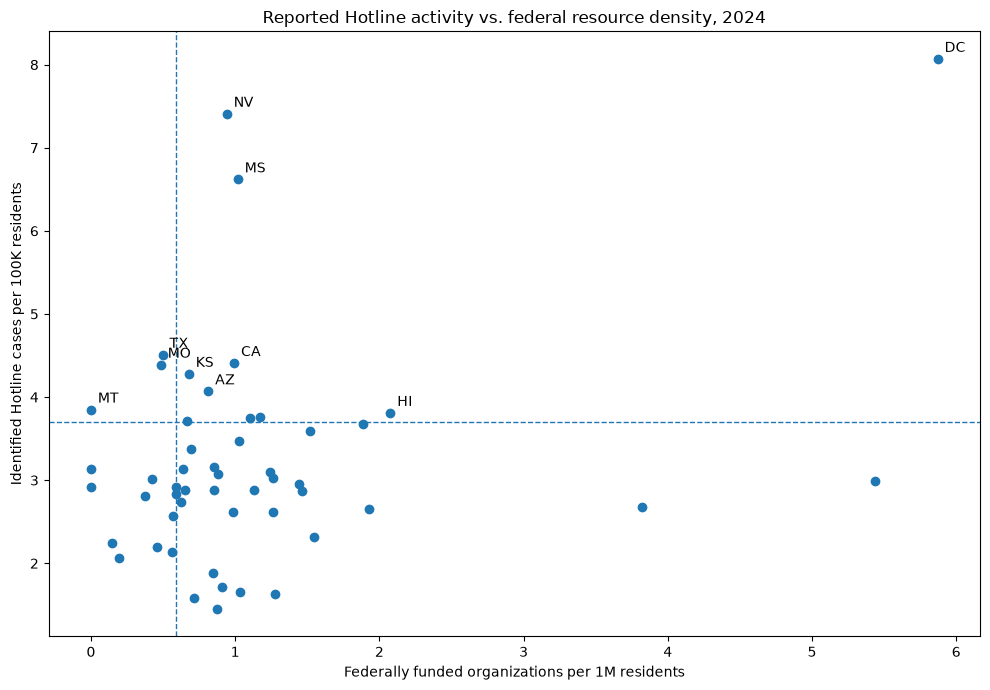

In [58]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 7))


plt.scatter(
    analysis["organizations_per_1m"],
    analysis["cases_per_100k"]
)


for _, row in (
    analysis
    .sort_values(
        "cases_per_100k",
        ascending=False
    )
    .head(10)
    .iterrows()
):

    plt.annotate(
        row["state_abbr"],
        (
            row["organizations_per_1m"],
            row["cases_per_100k"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )


plt.axvline(
    resource_threshold,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    reporting_threshold,
    linestyle="--",
    linewidth=1
)


plt.xlabel(
    "Federally funded organizations per 1M residents"
)

plt.ylabel(
    "Identified Hotline cases per 100K residents"
)

plt.title(
    "Reported Hotline activity vs. federal resource density, 2024"
)


plt.tight_layout()
plt.show()

## Reviewing the flagged jurisdictions

The flagged jurisdictions should be treated as starting points for deeper research rather than final conclusions.

A high reporting rate may reflect differences in awareness, reporting behavior, outreach, population characteristics, identification practices, or access to the Hotline.

Likewise, a low number of federally funded organizations does not mean that a jurisdiction lacks victim services. The federal awards analyzed here represent only one portion of the broader anti-trafficking service system.

The value of this analysis is therefore in identifying potential mismatches that deserve further investigation.

In [59]:
final_gap_table = (
    analysis[
        [
            "state",
            "state_abbr",
            "cases_identified",
            "cases_per_100k",
            "population_2024",
            "funded_organizations",
            "organizations_per_1m",
            "federal_awards",
            "awards_per_1m",
            "total_award_value",
            "poverty_rate",
            "unemployment_rate",
            "resource_pressure_signal"
        ]
    ]
    .sort_values(
        [
            "resource_pressure_signal",
            "cases_per_100k"
        ],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)


final_gap_table.head(20)

,state,state_abbr,cases_identified,cases_per_100k,population_2024,funded_organizations,organizations_per_1m,federal_awards,awards_per_1m,total_award_value,poverty_rate,unemployment_rate,resource_pressure_signal
0,Texas,TX,1360,4.51,30188424,15.0,0.496879,22.0,0.728756,15077734.37,13.8,5.3,True
1,Missouri,MO,272,4.39,6191814,3.0,0.484511,5.0,0.807518,3346205.72,12.6,4.0,True
2,Montana,MT,43,3.85,1116875,0.0,0.000000,0.0,0.000000,0.00,11.5,3.6,True
3,District of Columbia,DC,55,8.07,681294,4.0,5.871180,9.0,13.210156,8490525.18,15.4,6.3,False
4,Nevada,NV,236,7.41,3184612,3.0,0.942030,5.0,1.570050,3737365.84,12.4,7.0,False
5,Mississippi,MS,195,6.62,2946779,3.0,1.018061,3.0,1.018061,2099977.00,18.9,5.8,False
6,California,CA,1734,4.41,39287377,39.0,0.992685,61.0,1.552662,45858236.65,12.0,6.6,False
7,Kansas,KS,126,4.28,2947197,2.0,0.678611,2.0,0.678611,814511.77,11.3,3.9,False
8,Arizona,AZ,300,4.07,7378838,6.0,0.813136,8.0,1.084182,4898218.42,12.5,5.1,False
9,Hawaii,HI,55,3.81,1445235,3.0,2.075787,4.0,2.767716,2144594.16,10.0,4.9,False


## Saving the analysis-ready resource gap dataset

This file contains the combined state-level analysis used for the next stage of the project.

It preserves the original Hotline measures while adding federal resource measures and the exploratory resource-pressure flag.

In [60]:
gap_file = (
    clean_dir
    / "human_trafficking_resource_gap_2024.csv"
)


analysis.to_csv(
    gap_file,
    index=False
)


print("Saved resource-gap analysis:")
print(gap_file)

Saved resource-gap analysis:
C:\Users\skybo\OneDrive\Documents\human-trafficking-resource-gap-analysis\data\cleaned\human_trafficking_resource_gap_2024.csv


## Analysis checkpoint

At this stage, the project has moved from describing Hotline activity to comparing reported activity with a measurable federal resource footprint.

The resource-pressure flag is intentionally exploratory. It identifies jurisdictions where the two measures appear relatively misaligned, but it does not establish causation, prevalence, unmet need, or service insufficiency.

The next stage will focus on turning these findings into a small number of clear portfolio-quality visuals and an executive-level narrative.

In [61]:
def classify_resource_position(row):
    if (
        row["higher_reporting"]
        and row["lower_resource_density"]
    ):
        return "Potential Resource Pressure"

    if (
        row["higher_reporting"]
        and not row["lower_resource_density"]
    ):
        return "Higher Reporting + Higher Resources"

    if (
        not row["higher_reporting"]
        and row["lower_resource_density"]
    ):
        return "Lower Reporting + Lower Resources"

    return "Lower Reporting + Higher Resources"


analysis["resource_position"] = (
    analysis.apply(
        classify_resource_position,
        axis=1
    )
)


position_summary = (
    analysis["resource_position"]
    .value_counts()
    .rename_axis("resource_position")
    .reset_index(name="states")
)


position_summary

,resource_position,states
0,Lower Reporting + Higher Resources,28
1,Lower Reporting + Lower Resources,10
2,Higher Reporting + Higher Resources,10
3,Potential Resource Pressure,3


In [62]:
position_table = (
    analysis[
        [
            "state",
            "state_abbr",
            "cases_per_100k",
            "organizations_per_1m",
            "cases_identified",
            "funded_organizations",
            "resource_position"
        ]
    ]
    .sort_values(
        [
            "resource_position",
            "cases_per_100k"
        ],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)


position_table

,state,state_abbr,cases_per_100k,organizations_per_1m,cases_identified,funded_organizations,resource_position
0,District of Columbia,DC,8.07,5.871180,55,4.0,Higher Reporting + Higher Resources
1,Nevada,NV,7.41,0.942030,236,3.0,Higher Reporting + Higher Resources
2,Mississippi,MS,6.62,1.018061,195,3.0,Higher Reporting + Higher Resources
3,California,CA,4.41,0.992685,1734,39.0,Higher Reporting + Higher Resources
4,Kansas,KS,4.28,0.678611,126,2.0,Higher Reporting + Higher Resources
5,Arizona,AZ,4.07,0.813136,300,6.0,Higher Reporting + Higher Resources
6,Hawaii,HI,3.81,2.075787,55,3.0,Higher Reporting + Higher Resources
7,Oregon,OR,3.76,1.175283,160,5.0,Higher Reporting + Higher Resources
8,South Dakota,SD,3.75,1.102016,34,1.0,Higher Reporting + Higher Resources
9,Florida,FL,3.71,0.669163,832,15.0,Higher Reporting + Higher Resources


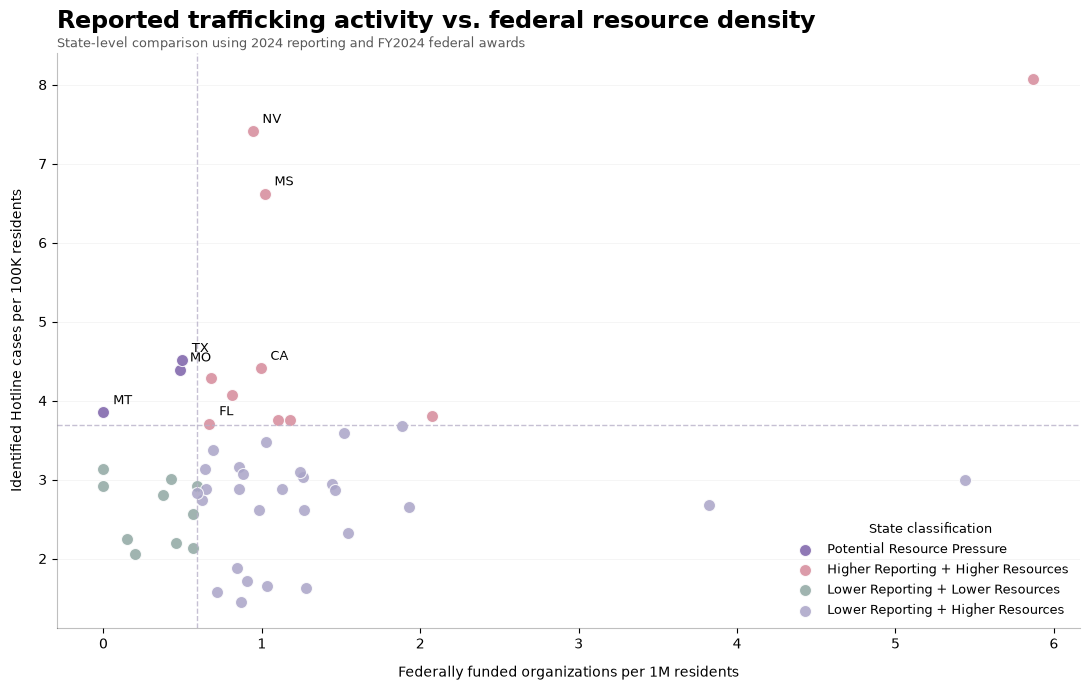

In [63]:
import matplotlib.pyplot as plt



plot_colors = {
    "Potential Resource Pressure": "#7B61A8",
    "Higher Reporting + Higher Resources": "#D58A9A",
    "Lower Reporting + Lower Resources": "#8FA7A3",
    "Lower Reporting + Higher Resources": "#A9A4C7"
}


fig, ax = plt.subplots(
    figsize=(11, 7)
)


position_groups = [
    "Potential Resource Pressure",
    "Higher Reporting + Higher Resources",
    "Lower Reporting + Lower Resources",
    "Lower Reporting + Higher Resources"
]


for group in position_groups:

    group_data = analysis[
        analysis["resource_position"] == group
    ]

    ax.scatter(
        group_data["organizations_per_1m"],
        group_data["cases_per_100k"],
        label=group,
        s=75,
        alpha=0.85,
        color=plot_colors[group],
        edgecolor="white",
        linewidth=0.8
    )


ax.axvline(
    resource_threshold,
    linestyle="--",
    linewidth=1,
    color="#B8B1C9",
    alpha=0.8
)

ax.axhline(
    reporting_threshold,
    linestyle="--",
    linewidth=1,
    color="#B8B1C9",
    alpha=0.8
)


states_to_label = [
    "Texas",
    "Missouri",
    "Montana",
    "Nevada",
    "Mississippi",
    "California",
    "Florida"
]


for _, row in analysis[
    analysis["state"].isin(states_to_label)
].iterrows():

    ax.annotate(
        row["state_abbr"],
        (
            row["organizations_per_1m"],
            row["cases_per_100k"]
        ),
        xytext=(7, 6),
        textcoords="offset points",
        fontsize=9,
        fontweight="normal"
    )


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_alpha(0.25)
ax.spines["bottom"].set_alpha(0.25)


ax.grid(
    axis="y",
    linestyle="-",
    linewidth=0.6,
    alpha=0.15
)

ax.set_axisbelow(True)


ax.set_xlabel(
    "Federally funded organizations per 1M residents",
    fontsize=10,
    labelpad=10
)

ax.set_ylabel(
    "Identified Hotline cases per 100K residents",
    fontsize=10,
    labelpad=10
)


ax.set_title(
    "Reported trafficking activity vs. federal resource density",
    fontsize=17,
    fontweight="bold",
    loc="left",
    pad=18
)


ax.text(
    0,
    1.01,
    "State-level comparison using 2024 reporting and FY2024 federal awards",
    transform=ax.transAxes,
    fontsize=9,
    alpha=0.65
)


ax.legend(
    title="State classification",
    frameon=False,
    fontsize=9,
    title_fontsize=9,
    loc="lower right"
)


plt.tight_layout()
plt.show()

## Where reported activity was highest

Population-adjusted reporting rates make it easier to compare states of different sizes.

This shows where the highest rates of identified trafficking cases were reported to the National Human Trafficking Hotline in 2024.

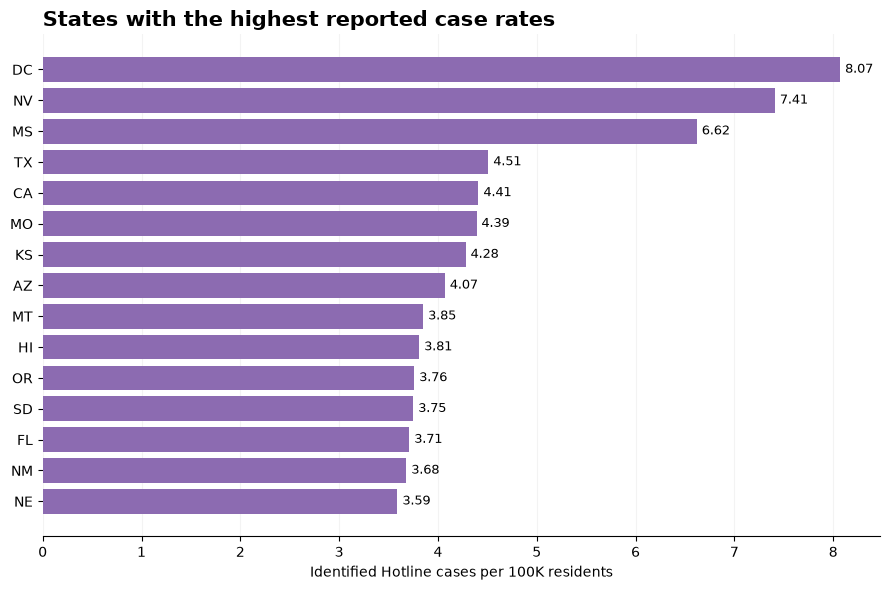

In [64]:
top_reporting = (
    analysis[
        [
            "state",
            "state_abbr",
            "cases_per_100k"
        ]
    ]
    .sort_values(
        "cases_per_100k",
        ascending=True
    )
    .tail(15)
)


fig, ax = plt.subplots(figsize=(9, 6))


ax.barh(
    top_reporting["state_abbr"],
    top_reporting["cases_per_100k"],
    color="#8C6BB1"
)


for i, value in enumerate(
    top_reporting["cases_per_100k"]
):
    ax.text(
        value + 0.05,
        i,
        f"{value:.2f}",
        va="center",
        fontsize=9
    )


ax.set_title(
    "States with the highest reported case rates",
    fontsize=15,
    fontweight="bold",
    loc="left"
)

ax.set_xlabel(
    "Identified Hotline cases per 100K residents"
)

ax.set_ylabel("")


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)


ax.grid(
    axis="x",
    alpha=0.15
)

ax.set_axisbelow(True)


plt.tight_layout()
plt.tight_layout()

plt.savefig(
    project_root / "images" / "top_reporting_rates.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Where federally funded resources were concentrated

This shows the number of OVC-funded organizations per 1 million residents in each state. It helps put the reported Hotline activity into the context of federally funded resource availability.

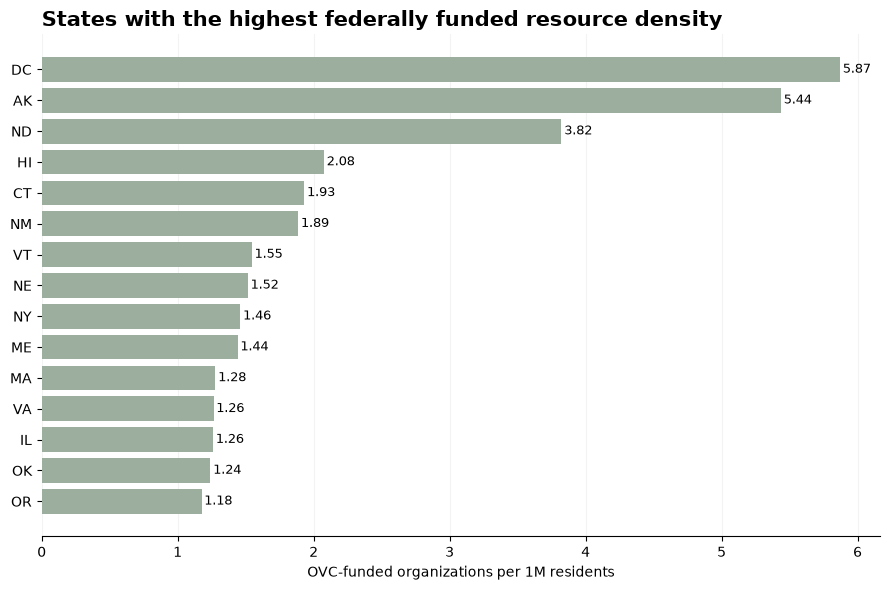

In [65]:
resource_density = (
    analysis[
        [
            "state",
            "state_abbr",
            "organizations_per_1m"
        ]
    ]
    .sort_values(
        "organizations_per_1m",
        ascending=True
    )
    .tail(15)
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    resource_density["state_abbr"],
    resource_density["organizations_per_1m"],
    color="#9CAF9F"
)

for i, value in enumerate(
    resource_density["organizations_per_1m"]
):
    ax.text(
        value + 0.02,
        i,
        f"{value:.2f}",
        va="center",
        fontsize=9
    )

ax.set_title(
    "States with the highest federally funded resource density",
    fontsize=15,
    fontweight="bold",
    loc="left"
)

ax.set_xlabel(
    "OVC-funded organizations per 1M residents"
)

ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(
    axis="x",
    alpha=0.15
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.tight_layout()

plt.savefig(
    project_root / "images" / "resource_density.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Reported activity compared with resource density

Looking at reporting activity and resource density together helps identify places where reported Hotline activity was relatively high while federally funded organizational density was relatively low. These areas are treated as potential resource-pressure signals, not as evidence of unmet need or trafficking prevalence.

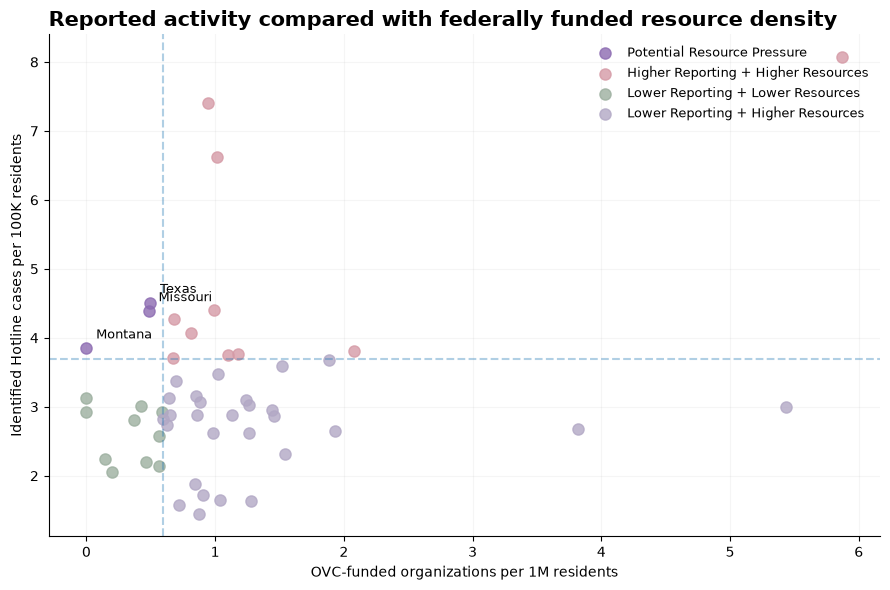

In [66]:
fig, ax = plt.subplots(figsize=(9, 6))

colors = {
    "Potential Resource Pressure": "#8C6BB1",
    "Higher Reporting + Higher Resources": "#D59AA6",
    "Lower Reporting + Lower Resources": "#9CAF9F",
    "Lower Reporting + Higher Resources": "#B2A8C5"
}

for group, color in colors.items():
    subset = analysis[
        analysis["resource_position"] == group
    ]

    ax.scatter(
        subset["organizations_per_1m"],
        subset["cases_per_100k"],
        s=65,
        alpha=0.8,
        color=color,
        label=group
    )

for state in ["Texas", "Missouri", "Montana"]:
    row = analysis[
        analysis["state"] == state
    ]

    if not row.empty:
        ax.annotate(
            state,
            (
                row["organizations_per_1m"].iloc[0],
                row["cases_per_100k"].iloc[0]
            ),
            xytext=(7, 7),
            textcoords="offset points",
            fontsize=9
        )

ax.axvline(
    analysis["organizations_per_1m"].quantile(0.25),
    linestyle="--",
    alpha=0.35
)

ax.axhline(
    analysis["cases_per_100k"].quantile(0.75),
    linestyle="--",
    alpha=0.35
)

ax.set_title(
    "Reported activity compared with federally funded resource density",
    fontsize=15,
    fontweight="bold",
    loc="left"
)

ax.set_xlabel(
    "OVC-funded organizations per 1M residents"
)

ax.set_ylabel(
    "Identified Hotline cases per 100K residents"
)

ax.legend(
    frameon=False,
    fontsize=9,
    loc="upper right"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    alpha=0.12
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.tight_layout()

plt.savefig(
    project_root / "images" / "resource_pressure_quadrant.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Socioeconomic context

Socioeconomic measures provide additional context for the state-level patterns in reported Hotline activity. These comparisons are descriptive and do not establish that income, poverty, or unemployment cause differences in trafficking reports.

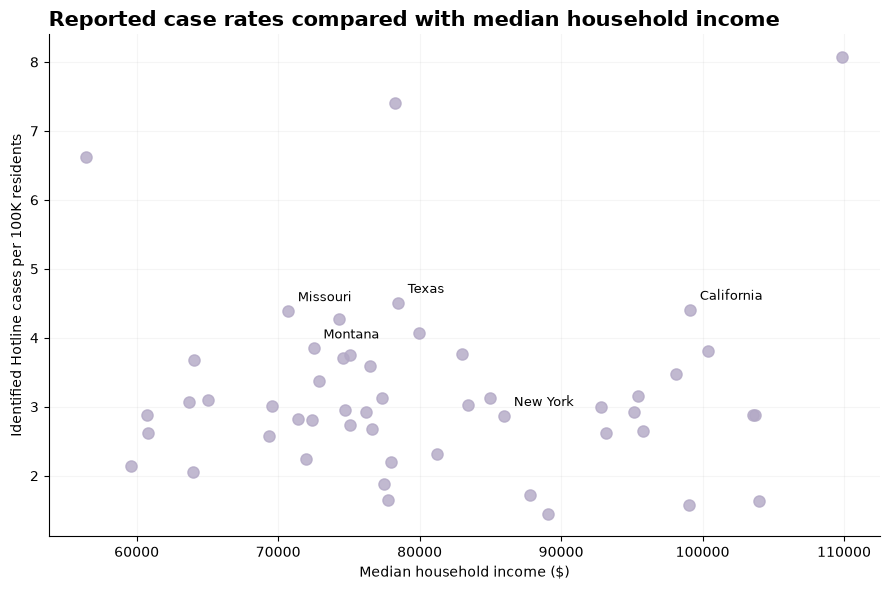

In [67]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    analysis["median_household_income"],
    analysis["cases_per_100k"],
    s=65,
    color="#B2A8C5",
    alpha=0.8
)

for state in ["Texas", "Missouri", "Montana", "New York", "California"]:
    row = analysis[
        analysis["state"] == state
    ]

    if not row.empty:
        ax.annotate(
            state,
            (
                row["median_household_income"].iloc[0],
                row["cases_per_100k"].iloc[0]
            ),
            xytext=(7, 7),
            textcoords="offset points",
            fontsize=9
        )

ax.set_title(
    "Reported case rates compared with median household income",
    fontsize=15,
    fontweight="bold",
    loc="left"
)

ax.set_xlabel(
    "Median household income ($)"
)

ax.set_ylabel(
    "Identified Hotline cases per 100K residents"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    alpha=0.12
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.tight_layout()

plt.savefig(
    project_root / "images" / "income_vs_reporting.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [68]:
from pathlib import Path

project_root = next(
    parent
    for parent in Path.cwd().parents
    if parent.name == "human-trafficking-resource-gap-analysis"
)

output_path = (
    project_root
    / "data"
    / "cleaned"
    / "final_gap_analysis_fy2024.csv"
)

analysis.to_csv(
    output_path,
    index=False
)

print(f"Saved final dataset to: {output_path}")
print(f"Rows: {len(analysis):,}")
print(f"Columns: {len(analysis.columns):,}")

Saved final dataset to: c:\Users\skybo\OneDrive\Documents\human-trafficking-resource-gap-analysis\data\cleaned\final_gap_analysis_fy2024.csv
Rows: 51
Columns: 32


In [69]:
final_gap = pd.read_csv(
    output_path
)

final_gap.head()

,state,signals_received,pct_total_signals,cases_identified,pct_total_cases,year,state_abbr,state_fips,signals_per_case,raw_case_rank,...,federal_awards,funded_organizations,total_award_value,organizations_per_1m,awards_per_1m,cases_per_funded_organization,higher_reporting,lower_resource_density,resource_pressure_signal,resource_position
0,Alabama,231,0.71,105,0.87,2024,AL,1,2.20,30,...,1.0,1.0,681730.84,0.196588,0.196588,105.000000,False,True,False,Lower Reporting + Lower Resources
1,Alaska,46,0.14,22,0.18,2024,AK,2,2.09,46,...,6.0,4.0,3976913.58,5.436954,8.155432,5.500000,False,False,False,Lower Reporting + Higher Resources
2,Arizona,550,1.70,300,2.50,2024,AZ,4,1.83,10,...,8.0,6.0,4898218.42,0.813136,1.084182,50.000000,True,False,False,Higher Reporting + Higher Resources
3,Arkansas,170,0.53,80,0.67,2024,AR,5,2.12,35,...,3.0,3.0,2450000.00,0.983803,0.983803,26.666667,False,False,False,Lower Reporting + Higher Resources
4,California,3378,10.46,1734,14.45,2024,CA,6,1.95,1,...,61.0,39.0,45858236.65,0.992685,1.552662,44.461538,True,False,False,Higher Reporting + Higher Resources


## Key findings

### 1. Population size changes the picture

Raw case counts tend to favor larger states, so population-adjusted rates provide a different view of reported Hotline activity. In 2024, the highest reported case rates were concentrated in a smaller group of jurisdictions, including the District of Columbia, Nevada, Mississippi, Texas, California, and Missouri.

### 2. Resource availability varied considerably

OVC-funded organizational density differed substantially across jurisdictions. Some smaller jurisdictions had relatively high numbers of federally funded organizations per 1 million residents, while several larger states had much lower organizational density.

### 3. Three jurisdictions showed a potential resource-pressure signal

Texas, Missouri, and Montana fell into the combination of relatively high reported case rates and relatively low OVC-funded organizational density used in this analysis. These results should be treated as areas for further investigation rather than evidence of a confirmed resource shortage.

### 4. Reported activity was not strongly related to household income

The Spearman correlation between reported cases per 100,000 residents and median household income was approximately -0.02, indicating little monotonic relationship in this dataset. Poverty and unemployment showed weak positive correlations of approximately 0.27 each.

### 5. The findings describe reported activity, not prevalence

Hotline data represent reports and identified cases received by the National Human Trafficking Hotline. They should not be interpreted as a measure of the true prevalence of human trafficking. Similarly, OVC-funded organizations represent federally funded resources captured by this dataset and not the full universe of available services.

## Limitations and methodology

This analysis combines National Human Trafficking Hotline reporting data, U.S. Census population and socioeconomic data, and federally funded OVC award data. Each source measures a different part of the issue, so the results should be interpreted as descriptive comparisons rather than estimates of trafficking prevalence or unmet service needs.

### Hotline data

National Human Trafficking Hotline data represent reports and identified cases received by the Hotline. They do not measure the true prevalence of human trafficking, and differences between states may reflect differences in awareness, reporting behavior, access to the Hotline, or other factors.

### Federal resource data

The resource measure is based on OVC-funded organizations identified through USAspending for the selected trafficking-related federal programs. This is a proxy for federally funded resource presence, not a complete count of trafficking service providers in each state.

### Resource-pressure classification

The potential resource-pressure signal was created by identifying jurisdictions in the upper quartile of reported cases per 100,000 residents and the lower quartile of OVC-funded organizations per 1 million residents. This classification is a screening method for further investigation, not a determination that a jurisdiction has insufficient services.

### Socioeconomic analysis

Income, poverty, and unemployment were included as contextual variables. The correlations in this analysis are descriptive and do not establish causation.

### Data coverage

The analysis uses 2024 state-level Hotline reporting data, 2024 ACS 5-year socioeconomic data, and OVC awards overlapping fiscal year 2024. Differences in reporting periods and data collection methods should be considered when interpreting comparisons across sources.

## Conclusion

This analysis shows why looking at reported trafficking activity and resource availability separately can miss important differences between jurisdictions.

Population-adjusted Hotline reporting rates provide a more comparable measure of reported activity across states, while OVC-funded organizational density provides a narrower view of federally funded resources. When the two measures are considered together, Texas, Missouri, and Montana emerge as jurisdictions with a potential resource-pressure signal under the methodology used here.

These findings are best viewed as a starting point for deeper research into service capacity, funding distribution, and local conditions rather than as a measure of trafficking prevalence or proof of unmet need.

In [70]:
final_gap_file = (
    clean_dir
    / "human_trafficking_resource_gap_2024.csv"
)


analysis.to_csv(
    final_gap_file,
    index=False
)


print("Final analysis dataset saved:")
print(final_gap_file)

print(
    "\nRows:",
    len(analysis)
)

print(
    "Columns:",
    len(analysis.columns)
)

Final analysis dataset saved:
C:\Users\skybo\OneDrive\Documents\human-trafficking-resource-gap-analysis\data\cleaned\human_trafficking_resource_gap_2024.csv

Rows: 51
Columns: 32
